In [29]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [3]:
dataset = pd.read_csv('TRAIN.csv')
dataset.head(5)

,F01,F02,F03,F04,F05,F06,F07,F08,F09,F10,...,F39,F40,F41,F42,F43,F44,F45,F46,F47,Class
0,0.185570,0.004568,0.005362,0.003335,0.005415,0.004895,0.012764,0.120138,0.140450,3.361753,...,0.041526,-0.230857,0.003310,0.042250,0.005975,0.002104,0.013878,0.001518,0.011347,0
1,0.369536,0.003983,0.003386,0.004902,0.007570,0.012136,0.118050,0.323925,0.132093,2.766117,...,-0.141285,-6.222857,0.834177,0.227968,0.018463,-0.020487,0.001246,0.007489,0.008724,1
2,0.602510,0.008442,0.012961,0.012870,0.046885,0.115401,0.065688,0.306677,0.498805,4.521201,...,0.011334,10.335251,-0.276614,-0.198900,-0.012756,0.014286,-0.001866,0.002687,0.013452,1
3,0.347957,0.064721,0.013611,0.011541,0.006492,0.008690,0.013192,0.164553,0.298665,3.170847,...,0.190479,2.864912,-1.921939,0.891690,1.108098,0.635431,0.081368,-0.000225,0.009166,0
4,0.233653,0.012217,0.010088,0.022095,0.026040,0.015062,0.016063,0.084648,0.213367,8.150943,...,0.203164,0.001812,-0.092731,0.005280,-0.213985,0.032195,0.002081,0.028930,-0.025912,1


In [5]:
dataset.tail(5)

,F01,F02,F03,F04,F05,F06,F07,F08,F09,F10,...,F39,F40,F41,F42,F43,F44,F45,F46,F47,Class
43771,1.231065,0.008631,0.010488,0.030072,0.224300,0.384893,0.452580,0.878004,0.583311,4.336341,...,0.076438,-10.673305,0.874835,0.035450,0.001390,-0.003333,0.002385,0.001182,-0.010616,1
43772,1.576213,0.019906,0.015115,0.034719,0.347274,0.913438,0.240656,0.469324,1.118124,3.395661,...,-0.033483,-19.302853,5.744947,0.373802,0.006406,-0.008244,-0.081317,-0.007015,-0.001864,1
43773,0.523951,0.006851,0.012379,0.008150,0.012631,0.012130,0.033749,0.150855,0.500064,3.677857,...,0.051253,0.825418,0.006428,-0.012533,-0.034026,0.000177,0.005071,0.005763,0.005489,0
43774,0.313915,0.003392,0.004212,0.004475,0.004765,0.005470,0.017687,0.034267,0.311377,2.097170,...,-0.012220,-0.630316,-0.006486,-0.042303,0.037734,0.039146,-0.008112,-0.001419,0.000728,1
43775,0.206646,0.014795,0.012043,0.020157,0.044076,0.029703,0.021559,0.108707,0.163788,3.503771,...,-0.034282,0.027310,-0.197855,-0.003869,-0.039651,-0.009938,0.006735,0.000255,-0.020324,1


In [4]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 43776 entries, 0 to 43775
Data columns (total 48 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   F01     43776 non-null  float64
 1   F02     43776 non-null  float64
 2   F03     43776 non-null  float64
 3   F04     43776 non-null  float64
 4   F05     43776 non-null  float64
 5   F06     43776 non-null  float64
 6   F07     43776 non-null  float64
 7   F08     43776 non-null  float64
 8   F09     43776 non-null  float64
 9   F10     43776 non-null  float64
 10  F11     43776 non-null  float64
 11  F12     43776 non-null  float64
 12  F13     43776 non-null  float64
 13  F14     43776 non-null  float64
 14  F15     43776 non-null  float64
 15  F16     43776 non-null  float64
 16  F17     43776 non-null  float64
 17  F18     43776 non-null  float64
 18  F19     43776 non-null  float64
 19  F20     43776 non-null  float64
 20  F21     43776 non-null  float64
 21  F22     43776 non-null  float64
 22  F23     4

In [6]:
missing_values = dataset.isnull().sum()
print(missing_values)

F01      0
F02      0
F03      0
F04      0
F05      0
F06      0
F07      0
F08      0
F09      0
F10      0
F11      0
F12      0
F13      0
F14      0
F15      0
F16      0
F17      0
F18      0
F19      0
F20      0
F21      0
F22      0
F23      0
F24      0
F25      0
F26      0
F27      0
F28      0
F29      0
F30      0
F31      0
F32      0
F33      0
F34      0
F35      0
F36      0
F37      0
F38      0
F39      0
F40      0
F41      0
F42      0
F43      0
F44      0
F45      0
F46      0
F47      0
Class    0
dtype: int64


In [8]:
x = dataset.drop('Class',axis=1)
y = dataset['Class']
print(x.shape)
print(y.shape)

(43776, 47)
(43776,)


In [12]:
x.head()


,F01,F02,F03,F04,F05,F06,F07,F08,F09,F10,...,F38,F39,F40,F41,F42,F43,F44,F45,F46,F47
0,0.185570,0.004568,0.005362,0.003335,0.005415,0.004895,0.012764,0.120138,0.140450,3.361753,...,2.826142,0.041526,-0.230857,0.003310,0.042250,0.005975,0.002104,0.013878,0.001518,0.011347
1,0.369536,0.003983,0.003386,0.004902,0.007570,0.012136,0.118050,0.323925,0.132093,2.766117,...,2.955462,-0.141285,-6.222857,0.834177,0.227968,0.018463,-0.020487,0.001246,0.007489,0.008724
2,0.602510,0.008442,0.012961,0.012870,0.046885,0.115401,0.065688,0.306677,0.498805,4.521201,...,3.423784,0.011334,10.335251,-0.276614,-0.198900,-0.012756,0.014286,-0.001866,0.002687,0.013452
3,0.347957,0.064721,0.013611,0.011541,0.006492,0.008690,0.013192,0.164553,0.298665,3.170847,...,2.473058,0.190479,2.864912,-1.921939,0.891690,1.108098,0.635431,0.081368,-0.000225,0.009166
4,0.233653,0.012217,0.010088,0.022095,0.026040,0.015062,0.016063,0.084648,0.213367,8.150943,...,7.595287,0.203164,0.001812,-0.092731,0.005280,-0.213985,0.032195,0.002081,0.028930,-0.025912


In [13]:
y.head()

0    0
1    1
2    1
3    0
4    1
Name: Class, dtype: int64

In [14]:
X_train, X_val, y_train, y_val = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [16]:
print(X_train.shape)
print(X_val.shape)
print(y_train.shape)
print(y_val.shape)

(35020, 47)
(8756, 47)
(35020,)
(8756,)


### Training Multiple Model and finalize the best one

In [26]:
# Decision tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train,y_train)
val_pred = dt.predict(X_val)
dt_acc = accuracy_score(y_val , val_pred)
print("Decision Tree Classification Report")
print(classification_report(y_val,val_pred))
print(f"Decision Tree accuracy: {dt_acc}")

Decision Tree Classification Report
              precision    recall  f1-score   support

           0       0.95      0.96      0.96      5292
           1       0.94      0.93      0.93      3464

    accuracy                           0.95      8756
   macro avg       0.94      0.94      0.94      8756
weighted avg       0.95      0.95      0.95      8756

Decision Tree accuracy: 0.9459798994974874


In [27]:
# Random Forest
rf = RandomForestClassifier(n_estimators=200,random_state=42)
rf.fit(X_train,y_train)
val_pred = rf.predict(X_val)
print("Random Forest Classification Report")
print(classification_report(y_val,val_pred))
rf_acc = accuracy_score(y_val , val_pred)
print(f"Random Forest Accuracy: {rf_acc}")

Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      5292
           1       0.99      0.96      0.97      3464

    accuracy                           0.98      8756
   macro avg       0.98      0.98      0.98      8756
weighted avg       0.98      0.98      0.98      8756

Random Forest Accuracy: 0.980470534490635


In [31]:
# Xgboost
xgb = XGBClassifier(n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss")
xgb.fit(X_train, y_train)
val_pred = xgb.predict(X_val)
print("XGBoost Classification Report")
print(classification_report(y_val,val_pred))
xgb_acc = accuracy_score(y_val , val_pred)
print(f"XGBoost Accuracy: {xgb_acc}")

c:\Users\Himanshu\Desktop\alrIEEEna_26_dataset\myenv\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:11:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classification Report
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      5292
           1       0.99      0.95      0.97      3464

    accuracy                           0.98      8756
   macro avg       0.98      0.97      0.97      8756
weighted avg       0.98      0.98      0.98      8756

XGBoost Accuracy: 0.9753312014618547


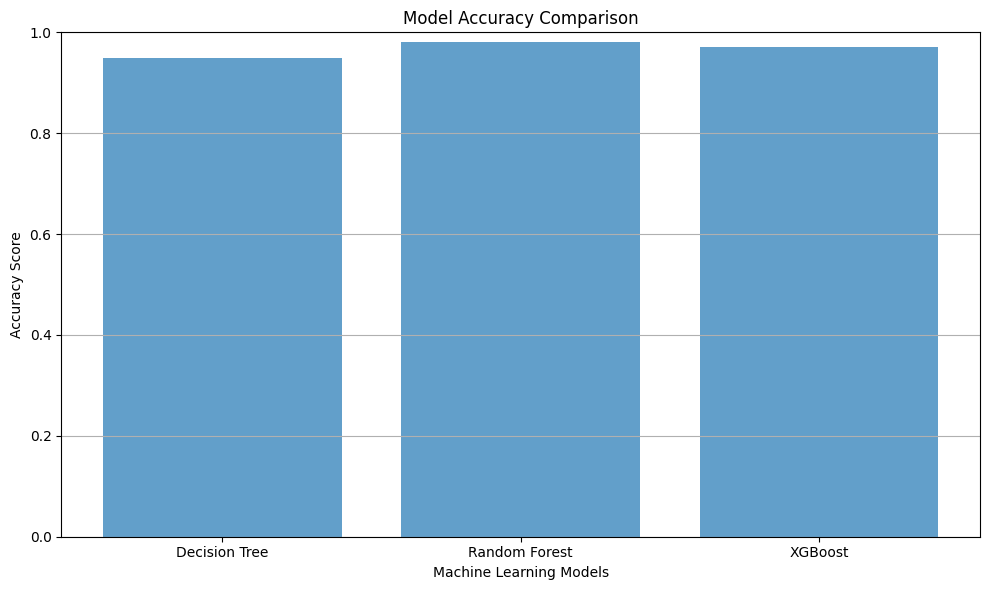

In [32]:
accuracy_scores = [0.95 , 0.98 , 0.97]
models = ['Decision Tree', 'Random Forest', 'XGBoost',]

x_pos = np.arange(len(models))
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x_pos, accuracy_scores, align='center', alpha=0.7, ecolor='black', capsize=10)
ax.set_ylabel('Accuracy Score')
ax.set_xlabel('Machine Learning Models')
ax.set_xticks(x_pos)
ax.set_xticklabels(models)
ax.set_title('Model Accuracy Comparison')
ax.set_ylim(0, 1)
ax.yaxis.grid(True)
plt.tight_layout()
plt.show()

Training Full dataset on random forest

In [38]:
rf.fit(x,y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [39]:
joblib.dump(rf, "rf_model.pkl")
print("Model saved successfully!")

Model saved successfully!
